<a href="https://colab.research.google.com/github/Fariborz-Eshraghi/force-openvla/blob/main/notebooks/main_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenVLA 7B Google Colab T4 Demo

This notebook sets up a simple OpenVLA inference/playground test on Google Colab. It is designed for a Tesla T4 with about 15 GB VRAM, so it defaults to 4-bit bitsandbytes loading and avoids FlashAttention.

Sources used for this notebook:
- OpenVLA repo: https://github.com/openvla/openvla
- OpenVLA model card: https://huggingface.co/openvla/openvla-7b
- Hugging Face bitsandbytes quantization docs: https://huggingface.co/docs/transformers/quantization/bitsandbytes

Important: OpenVLA predicts robot actions in a robot-specific action space. The output here is useful for verifying that inference works, but it is not automatically executable on every robot hand or simulator without the right controller, calibration, and action unnormalization setup.

In [1]:
%pip install -q --upgrade "pillow<12,>=10.0.0"

In [2]:
# Cell 1: GPU check
# In Colab: Runtime -> Change runtime type -> GPU.
# Expected for your setup: NVIDIA Tesla T4 and CUDA available.

!nvidia-smi

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    major, minor = torch.cuda.get_device_capability(0)
    print("CUDA capability:", f"{major}.{minor}")
else:
    raise RuntimeError("CUDA is not available. In Colab, enable GPU runtime before continuing.")

Fri May 15 14:24:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 Notes: Hugging Face Token Setup

1. Go to https://huggingface.co/settings/tokens
2. Click **Create new token**.
3. Choose **Read** access. A fine-grained read token is enough for downloading public or accessible models.
4. Copy the token once. It starts with `hf_...`.
5. In Colab, do not hardcode it in the notebook. Use `login()` and paste it into the secure prompt.

Optional Colab Secrets path: click the key icon in Colab's left sidebar, add a secret named `HF_TOKEN`, and then use the commented code below.

In [7]:
%pip install -q --upgrade \
  "huggingface_hub==0.34.6" \
  "requests==2.32.4" \
  "fsspec==2025.3.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.6/562.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.0 MB/s eta 0:00:00


In [9]:
# Cell 2: Hugging Face login
# Do not paste or save your token directly in this notebook.
# This opens a secure prompt in Colab.

from huggingface_hub import login

login()

# Optional Colab Secrets version:
#from google.colab import userdata
#hf_token = userdata.get("HF_TOKEN")
#login(token=hf_token)

In [11]:
#### Do not rerun Cell 3 unless something fails. ####

# Cell 3: Install dependencies
# OpenVLA's official minimal requirements pin transformers/tokenizers/timm.
# Colab already ships a CUDA-enabled torch build, so this cell avoids reinstalling torch.
# After this finishes, restart the runtime if Colab asks you to.

# Cell 3: Install dependencies
# Colab 4-bit OpenVLA loading is more reliable with transformers 4.49 + accelerate 1.1.1.

%pip install -q --upgrade \
  "transformers==4.49.0" \
  "tokenizers>=0.21,<0.22" \
  "timm==0.9.10" \
  "accelerate==1.1.1" \
  "bitsandbytes>=0.45.5" \
  "huggingface_hub==0.34.6" \
  "requests==2.32.4" \
  "fsspec==2025.3.0" \
  "pillow<12,>=10.0.0" \
  "einops"


In [14]:
# Cell 4: Import checks

import importlib.metadata as md
import torch
import torchvision
import transformers
import accelerate
import bitsandbytes as bnb
import timm
import tokenizers
import PIL

packages = [
    "torch",
    "torchvision",
    "transformers",
    "accelerate",
    "bitsandbytes",
    "huggingface_hub",
    "Pillow",
    "einops",
    "timm",
    "tokenizers",
]

for name in packages:
    try:
        print(f"{name}: {md.version(name)}")
    except md.PackageNotFoundError:
        print(f"{name}: not found")

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
transformers: 4.49.0
accelerate: 1.1.1
bitsandbytes: 0.49.2
huggingface_hub: 0.34.6
Pillow: 11.3.0
einops: 0.8.2
timm: 0.9.10
tokenizers: 0.21.4
CUDA available: True
GPU: Tesla T4


In [15]:
# Cell 5: Load processor/model efficiently
# Default: 4-bit quantized OpenVLA 7B for a Tesla T4.
# This can take several minutes the first time because the model weights are downloaded.

import gc
import torch
from transformers import AutoModelForVision2Seq, AutoProcessor, BitsAndBytesConfig

MODEL_ID = "openvla/openvla-7b"
UNNORM_KEY = "bridge_orig"
COMPUTE_DTYPE = torch.float16  # T4 supports fp16. T4 does not support bf16 well.

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def gpu_memory(label):
    if not torch.cuda.is_available():
        print(f"{label}: CUDA is not available")
        return
    free, total = torch.cuda.mem_get_info()
    allocated = torch.cuda.memory_allocated()
    reserved = torch.cuda.memory_reserved()
    print(f"{label} GPU memory")
    print(f"  free:      {free / 1024**3:.2f} GiB / {total / 1024**3:.2f} GiB")
    print(f"  allocated: {allocated / 1024**3:.2f} GiB")
    print(f"  reserved:  {reserved / 1024**3:.2f} GiB")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Enable a GPU runtime before loading OpenVLA.")

cleanup_memory()
gpu_memory("Before loading")

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

vla = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    attn_implementation="eager",
    torch_dtype=COMPUTE_DTYPE,
    quantization_config=quantization_config,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

vla.eval()


gpu_memory("After loading")
print("Device map:", getattr(vla, "hf_device_map", "No device_map attribute"))

try:
    print(f"Model memory footprint: {vla.get_memory_footprint() / 1024**3:.2f} GiB")
except Exception as exc:
    print("Could not read model memory footprint:", repr(exc))

Before loading GPU memory
  free:      14.46 GiB / 14.56 GiB
  allocated: 0.00 GiB
  reserved:  0.00 GiB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/130 [00:00<?, ?B/s]

processing_prismatic.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openvla/openvla-7b:
- processing_prismatic.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00002-of-00003.safetensors:   0%|          | 0.00/6.97G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/1.16G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

After loading GPU memory
  free:      10.24 GiB / 14.56 GiB
  allocated: 4.05 GiB
  reserved:  4.21 GiB
Device map: {'': 0}
Model memory footprint: 3.88 GiB


Current robot/hand state:
hand_type: 5-finger robotic hand
wrist_xy_pixels: (315, 230)
gripper_state: open
target_object: red block
tactile_values: {'thumb_tip': 0.05, 'index_tip': 0.02, 'middle_tip': 0.0, 'ring_tip': 0.0, 'little_tip': 0.0, 'palm': 0.0}
Image shape: (420, 640, 3)


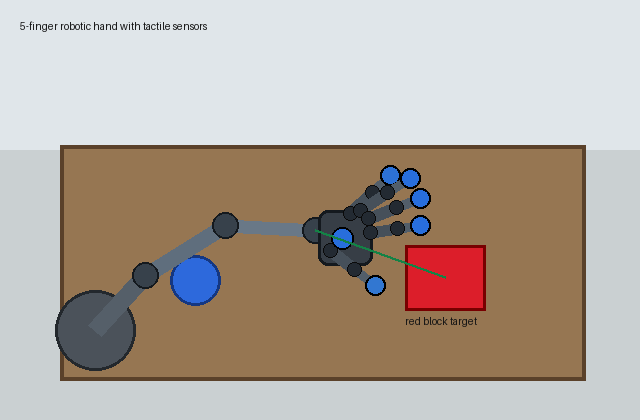

In [16]:
# Cell 6: Synthetic 5-finger robotic hand + tactile sensors

from PIL import Image, ImageDraw
from IPython.display import display
import numpy as np
import math

width, height = 640, 420
image = Image.new("RGB", (width, height), color=(230, 235, 238))
draw = ImageDraw.Draw(image)

# Scene
draw.rectangle([0, 0, width, 150], fill=(224, 230, 234))
draw.rectangle([0, 150, width, height], fill=(202, 208, 210))

table = [60, 145, 585, 380]
draw.rectangle(table, fill=(150, 118, 82), outline=(90, 65, 42), width=4)

# Objects
red_block = [405, 245, 485, 310]
blue_object = [170, 255, 220, 305]
draw.rectangle(red_block, fill=(220, 30, 42), outline=(120, 0, 0), width=3)
draw.ellipse(blue_object, fill=(45, 105, 220), outline=(20, 55, 130), width=3)

# Robot arm and wrist
base_center = (95, 330)
shoulder = (145, 275)
elbow = (225, 225)
wrist = (315, 230)

draw.ellipse([55, 290, 135, 370], fill=(75, 82, 90), outline=(35, 40, 45), width=3)
draw.line([base_center, shoulder], fill=(85, 95, 105), width=18)
draw.line([shoulder, elbow], fill=(95, 110, 125), width=16)
draw.line([elbow, wrist], fill=(105, 120, 135), width=14)

for p in [shoulder, elbow, wrist]:
    x, y = p
    draw.ellipse([x-13, y-13, x+13, y+13], fill=(55, 65, 75), outline=(20, 25, 30), width=2)

# Robotic hand palm
palm_center = np.array([345, 235])
palm = [318, 210, 372, 265]
draw.rounded_rectangle(palm, radius=10, fill=(55, 62, 70), outline=(20, 25, 30), width=3)

# Five fingers with tactile pads
finger_specs = [
    ("thumb",  (330, 250), (375, 285), -20),
    ("index",  (350, 213), (390, 175), -35),
    ("middle", (360, 210), (410, 178), -25),
    ("ring",   (368, 218), (420, 198), -12),
    ("little", (370, 232), (420, 225), 0),
]

finger_tip_points = {}
tactile_values = {
    "thumb_tip": 0.05,
    "index_tip": 0.02,
    "middle_tip": 0.00,
    "ring_tip": 0.00,
    "little_tip": 0.00,
    "palm": 0.00,
}

def pressure_color(v):
    # blue = no pressure, yellow/red = contact pressure
    v = float(np.clip(v, 0, 1))
    r = int(40 + 215 * v)
    g = int(110 + 90 * (1 - abs(v - 0.5) * 2))
    b = int(220 * (1 - v))
    return (r, g, b)

for name, root, tip, angle in finger_specs:
    root = np.array(root)
    tip = np.array(tip)

    mid = root + 0.55 * (tip - root)
    draw.line([tuple(root), tuple(mid)], fill=(70, 80, 90), width=12)
    draw.line([tuple(mid), tuple(tip)], fill=(82, 94, 106), width=10)

    for joint in [root, mid, tip]:
        x, y = joint
        draw.ellipse([x-7, y-7, x+7, y+7], fill=(35, 42, 50), outline=(10, 10, 10), width=1)

    sensor_name = f"{name}_tip"
    finger_tip_points[sensor_name] = tuple(tip.astype(int))

    pressure = tactile_values.get(sensor_name, 0.0)
    x, y = tip
    draw.ellipse(
        [x-10, y-10, x+10, y+10],
        fill=pressure_color(pressure),
        outline=(0, 0, 0),
        width=2,
    )

# Palm tactile sensor
palm_pressure = tactile_values["palm"]
draw.ellipse(
    [342-11, 238-11, 342+11, 238+11],
    fill=pressure_color(palm_pressure),
    outline=(0, 0, 0),
    width=2,
)

# Labels and target
target_center = ((red_block[0] + red_block[2]) // 2, (red_block[1] + red_block[3]) // 2)
draw.line([wrist, target_center], fill=(20, 130, 70), width=3)
draw.text((20, 20), "5-finger robotic hand with tactile sensors", fill=(20, 20, 20))
draw.text((405, 315), "red block target", fill=(20, 20, 20))

robot_state = {
    "hand_type": "5-finger robotic hand",
    "wrist_xy_pixels": wrist,
    "gripper_state": "open",
    "target_object": "red block",
    "tactile_values": tactile_values,
}

image = image.convert("RGB")
image_np = np.array(image)

print("Current robot/hand state:")
for k, v in robot_state.items():
    print(f"{k}: {v}")

print("Image shape:", image_np.shape)
display(image)


In [17]:
# Cell 6B: Physically cleaner simulated tactile input
# Tactile force is zero unless a fingertip sensor actually touches/overlaps the red block.
# We also compute "proximity" separately, because proximity is not force.

import numpy as np

finger_order = ["thumb_tip", "index_tip", "middle_tip", "ring_tip", "little_tip"]

SENSOR_RADIUS_PX = 10.0      # matches the tactile pad circles drawn in Cell 6
CONTACT_NOISE = 0.005        # tiny fake sensor noise
MAX_PENETRATION_PX = 18.0    # deeper overlap -> stronger pressure

def point_to_rect_distance(point, rect):
    px, py = point
    x1, y1, x2, y2 = rect

    dx = max(x1 - px, 0, px - x2)
    dy = max(y1 - py, 0, py - y2)

    if dx == 0 and dy == 0:
        return 0.0

    return float(np.sqrt(dx * dx + dy * dy))

def simulate_tactile_history_contact_only(
    finger_tip_points,
    red_block,
    history_len=6,
    sensor_radius_px=SENSOR_RADIUS_PX,
):
    target_center = np.array([
        (red_block[0] + red_block[2]) / 2,
        (red_block[1] + red_block[3]) / 2,
    ], dtype=float)

    current_readings = []
    proximity_values = []
    debug_rows = []

    for finger in finger_order:
        tip = np.array(finger_tip_points[finger], dtype=float)
        distance_to_block = point_to_rect_distance(tip, red_block)

        # Gap between edge of tactile pad and edge of block.
        # Positive gap = not touching.
        # Negative gap = overlap/contact.
        gap = distance_to_block - sensor_radius_px
        penetration = max(0.0, -gap)

        # Force only exists during contact.
        if penetration > 0:
            normal = min(1.0, penetration / MAX_PENETRATION_PX)
        else:
            normal = 0.0

        # Optional tiny noise. Keep it very small.
        normal = float(np.clip(normal + np.random.normal(0.0, CONTACT_NOISE), 0.0, 1.0))

        # Proximity is separate from tactile force.
        # This can be useful for visualization, but it is not contact pressure.
        proximity = float(np.exp(-((max(gap, 0.0) / 45.0) ** 2)))

        # Shear force should also require contact.
        # Without real motion/slip dynamics, keep shear zero unless contact exists.
        if normal > 0.02:
            direction = target_center - tip
            direction_norm = np.linalg.norm(direction)

            if direction_norm > 1e-6:
                direction = direction / direction_norm
            else:
                direction = np.array([0.0, 0.0])

            shear_x = float(0.15 * normal * direction[0])
            shear_y = float(0.15 * normal * direction[1])
        else:
            shear_x = 0.0
            shear_y = 0.0

        current_readings.append([normal, shear_x, shear_y])
        proximity_values.append(proximity)

        debug_rows.append({
            "finger": finger,
            "tip_xy": tip.tolist(),
            "distance_to_block": distance_to_block,
            "sensor_gap": gap,
            "penetration": penetration,
            "normal": normal,
            "shear_x": shear_x,
            "shear_y": shear_y,
            "proximity_not_force": proximity,
        })

    current_readings = np.array(current_readings, dtype=np.float32)
    proximity_values = np.array(proximity_values, dtype=np.float32)

    # Temporal tactile history: no growing fake pressure unless contact exists.
    tactile_history = np.stack(
        [current_readings for _ in range(history_len)],
        axis=0,
    )

    return tactile_history, current_readings, proximity_values, debug_rows

tactile_history, tactile_now, tactile_proximity, tactile_debug = simulate_tactile_history_contact_only(
    finger_tip_points=finger_tip_points,
    red_block=red_block,
    history_len=6,
)

print("tactile_history shape:", tactile_history.shape)
print("Format: [time, finger, channel]")
print("Channels: normal_force, shear_x, shear_y")
print("Important: proximity is computed separately and is NOT force.\n")

for row in tactile_debug:
    print(
        f"{row['finger']:12s} "
        f"tip={row['tip_xy']} "
        f"distance={row['distance_to_block']:.1f}px "
        f"gap={row['sensor_gap']:.1f}px "
        f"penetration={row['penetration']:.1f}px "
        f"normal={row['normal']:.3f} "
        f"shear=({row['shear_x']:.3f}, {row['shear_y']:.3f}) "
        f"proximity={row['proximity_not_force']:.3f}"
    )


tactile_history shape: (6, 5, 3)
Format: [time, finger, channel]
Channels: normal_force, shear_x, shear_y
Important: proximity is computed separately and is NOT force.

thumb_tip    tip=[375.0, 285.0] distance=30.0px gap=20.0px penetration=0.0px normal=0.002 shear=(0.000, 0.000) proximity=0.821
index_tip    tip=[390.0, 175.0] distance=71.6px gap=61.6px penetration=0.0px normal=0.001 shear=(0.000, 0.000) proximity=0.154
middle_tip   tip=[410.0, 178.0] distance=67.0px gap=57.0px penetration=0.0px normal=0.000 shear=(0.000, 0.000) proximity=0.201
ring_tip     tip=[420.0, 198.0] distance=47.0px gap=37.0px penetration=0.0px normal=0.006 shear=(0.000, 0.000) proximity=0.509
little_tip   tip=[420.0, 225.0] distance=20.0px gap=10.0px penetration=0.0px normal=0.000 shear=(0.000, 0.000) proximity=0.952


In [18]:
# Cell 7: Create instruction with tactile context

instruction = "pick up the red block"

def tactile_to_text(tactile_now, threshold=0.25):
    contacts = []

    for finger, values in zip(finger_order, tactile_now):
        normal, shear_x, shear_y = values
        if normal >= threshold:
            contacts.append(f"{finger} has contact pressure {normal:.2f}")

    max_pressure = float(tactile_now[:, 0].max())
    mean_pressure = float(tactile_now[:, 0].mean())

    if len(contacts) == 0:
        contact_text = "No fingertip has firm contact with the object yet."
    else:
        contact_text = " ".join(contacts)

    if max_pressure < 0.15:
        state_text = "The hand is still approaching the object."
    elif max_pressure < 0.55:
        state_text = "The hand has light contact and should continue closing carefully."
    else:
        state_text = "The hand has strong contact and should avoid crushing the object."

    return (
        f"Tactile sensor summary: {contact_text} "
        f"Maximum pressure is {max_pressure:.2f}. "
        f"Mean pressure is {mean_pressure:.2f}. "
        f"{state_text}"
    )

tactile_text = tactile_to_text(tactile_now)

prompt = (
    f"In: The robot has a 5-finger hand with tactile sensors. "
    f"{tactile_text} "
    f"What action should the robot take to {instruction}?\nOut: "
)

print("Instruction:", instruction)
print("Tactile text:")
print(tactile_text)
print("\nPrompt:")
print(repr(prompt))


Instruction: pick up the red block
Tactile text:
Tactile sensor summary: No fingertip has firm contact with the object yet. Maximum pressure is 0.01. Mean pressure is 0.00. The hand is still approaching the object.

Prompt:
'In: The robot has a 5-finger hand with tactile sensors. Tactile sensor summary: No fingertip has firm contact with the object yet. Maximum pressure is 0.01. Mean pressure is 0.00. The hand is still approaching the object. What action should the robot take to pick up the red block?\nOut: '


In [19]:
# Cell 8: Run inference
# The output is a 7-DoF robot action vector for the chosen unnormalization key.

import time
import numpy as np
import torch

device = "cuda:0"

inputs = processor(prompt, image).to(device, dtype=COMPUTE_DTYPE)

print("Processor output keys:", list(inputs.keys()))
for key, value in inputs.items():
    if hasattr(value, "shape"):
        print(f"  {key}: shape={tuple(value.shape)}, dtype={value.dtype}, device={value.device}")

with torch.inference_mode():
    start = time.time()

    # Fix dtype mismatch on T4/4-bit loading:
    # forces CUDA matmul ops to use fp16 instead of mixing float32/bfloat16.
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        action = vla.predict_action(
            **inputs,
            unnorm_key=UNNORM_KEY,
            do_sample=False,
            use_cache=False,
        )

    elapsed = time.time() - start


print("Instruction:", instruction)
print("Image shape:", np.array(image).shape)
print("Predicted action:", action)
print("Action Python type:", type(action))
print(f"Inference time: {elapsed:.2f} seconds")
gpu_memory("After inference")

Processor output keys: ['input_ids', 'attention_mask', 'pixel_values']
  input_ids: shape=(1, 82), dtype=torch.int64, device=cuda:0
  attention_mask: shape=(1, 82), dtype=torch.int64, device=cuda:0
  pixel_values: shape=(1, 6, 224, 224), dtype=torch.float16, device=cuda:0
Instruction: pick up the red block
Image shape: (420, 640, 3)
Predicted action: [ 0.00314633  0.02968554 -0.00361897 -0.01610374 -0.03829302 -0.03069087
  0.        ]
Action Python type: <class 'numpy.ndarray'>
Inference time: 5.38 seconds
After inference GPU memory
  free:      9.76 GiB / 14.56 GiB
  allocated: 4.06 GiB
  reserved:  4.67 GiB


In [20]:
# Cell 9: Inspect action output
# OpenVLA actions are usually 7 numbers:
# [delta_x, delta_y, delta_z, delta_roll, delta_pitch, delta_yaw, gripper]
# These numbers are not universal robot commands. They only make sense with the right robot/controller.

import numpy as np
import torch

if isinstance(action, torch.Tensor):
    action_array = action.detach().cpu().float().numpy()
else:
    action_array = np.asarray(action)

flat_action = action_array.reshape(-1)

print("Raw action:", action)
print("Numpy dtype:", action_array.dtype)
print("Numpy shape:", action_array.shape)
print("Flat action list:", flat_action.tolist())

labels = ["delta_x", "delta_y", "delta_z", "delta_roll", "delta_pitch", "delta_yaw", "gripper"]
if flat_action.size == 7:
    print("\nLabeled 7-DoF action:")
    for label, value in zip(labels, flat_action):
        print(f"  {label}: {float(value): .6f}")
else:
    print(f"\nUnexpected action length: {flat_action.size}")
    print("This can happen if the model/config returns a different action representation.")

Raw action: [ 0.00314633  0.02968554 -0.00361897 -0.01610374 -0.03829302 -0.03069087
  0.        ]
Numpy dtype: float64
Numpy shape: (7,)
Flat action list: [0.003146326296469725, 0.029685540797079225, -0.0036189723957110904, -0.016103736529163387, -0.038293021445765234, -0.030690874741357954, 0.0]

Labeled 7-DoF action:
  delta_x:  0.003146
  delta_y:  0.029686
  delta_z: -0.003619
  delta_roll: -0.016104
  delta_pitch: -0.038293
  delta_yaw: -0.030691
  gripper:  0.000000


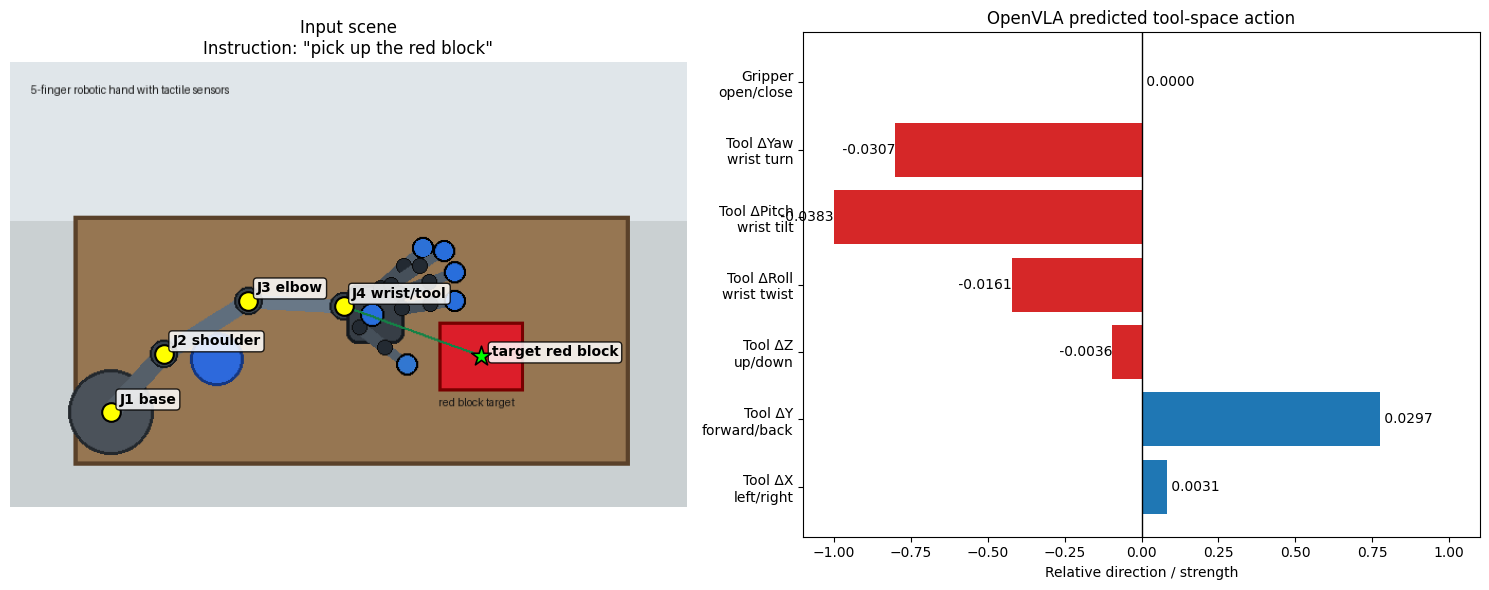

In [21]:
# Cell 9B: Human-friendly visualization with accurate action names and joint tags

import numpy as np
import matplotlib.pyplot as plt

action_array = np.asarray(action).reshape(-1)

labels = [
    "Tool ΔX\nleft/right",
    "Tool ΔY\nforward/back",
    "Tool ΔZ\nup/down",
    "Tool ΔRoll\nwrist twist",
    "Tool ΔPitch\nwrist tilt",
    "Tool ΔYaw\nwrist turn",
    "Gripper\nopen/close",
]

max_abs = max(np.max(np.abs(action_array)), 1e-6)
display_values = action_array / max_abs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: image with joint tags
axes[0].imshow(image)
axes[0].set_title(f'Input scene\nInstruction: "{instruction}"')
axes[0].axis("off")

# These variables come from the enhanced Cell 6 robot drawing.
joint_points = {
    "J1 base": base_center,
    "J2 shoulder": shoulder,
    "J3 elbow": elbow,
    "J4 wrist/tool": wrist,
}

for label, (x, y) in joint_points.items():
    axes[0].scatter(x, y, s=180, color="yellow", edgecolor="black", linewidth=1.5, zorder=5)
    axes[0].text(
        x + 8,
        y - 8,
        label,
        color="black",
        fontsize=10,
        weight="bold",
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.85, boxstyle="round,pad=0.25"),
        zorder=6,
    )

# Mark target object
rx = (red_block[0] + red_block[2]) / 2
ry = (red_block[1] + red_block[3]) / 2
axes[0].scatter(rx, ry, s=220, marker="*", color="lime", edgecolor="black", linewidth=1.2, zorder=7)
axes[0].text(
    rx + 10,
    ry,
    "target red block",
    fontsize=10,
    weight="bold",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.85, boxstyle="round,pad=0.25"),
)

# Right: accurate action vector labels
colors = ["tab:blue" if v >= 0 else "tab:red" for v in display_values]
axes[1].barh(labels, display_values, color=colors)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(-1.1, 1.1)
axes[1].set_title("OpenVLA predicted tool-space action")
axes[1].set_xlabel("Relative direction / strength")

for i, raw_value in enumerate(action_array):
    axes[1].text(
        display_values[i],
        i,
        f" {raw_value:.4f}",
        va="center",
        ha="left" if display_values[i] >= 0 else "right",
    )

plt.tight_layout()
plt.show()


Corrected interpretation
The model output is still the 7-value OpenVLA action vector.
The green circle below is a human-friendly visual next hand position toward the target.
It is not a direct pixel projection of OpenVLA's raw action vector.

Raw OpenVLA action vector:
[0.003146326296469725, 0.029685540797079225, -0.0036189723957110904, -0.016103736529163387, -0.038293021445765234, -0.030690874741357954, 0.0]

Image-space geometry:
Current wrist position: [315.0, 230.0]
Desired grasp target:   [435.0, 257.5]
Required movement:      dx=120.0px, dy=27.5px
Required distance:      123.1px
Visual next position:   [358.86295433377234, 240.05192703482282]

Approximate 2D IK joint estimate:
J2 shoulder: current=-32.0°, target=-3.5°, delta=28.5°
J3 elbow:    current=35.2°, target=0.0°, delta=-35.2°

Important:
For real joint rotations, you need the exact robot hand/arm model, camera calibration, and inverse kinematics.
OpenVLA gives a high-level tool/action-space command, not direct motor angle

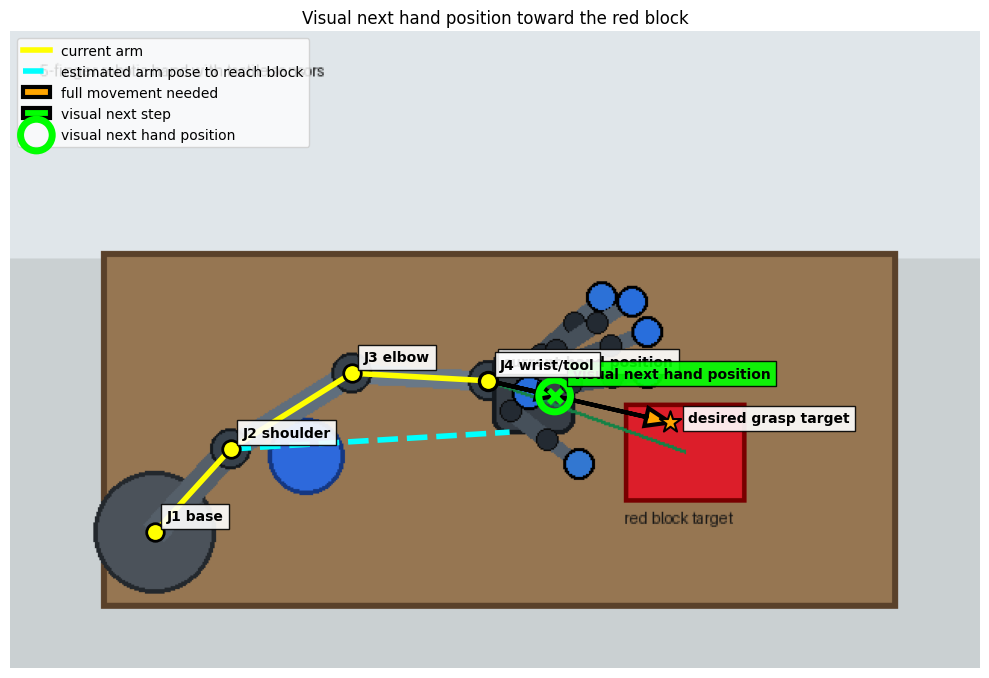

In [22]:
# Cell 9C: Corrected human-friendly motion visualization
# Shows:
# 1. Current robot hand position
# 2. Visual next hand position toward the red block
# 3. Full movement needed to reach the red block
# 4. Approximate 2D IK pose needed to reach the block
#
# Important:
# OpenVLA's raw action vector is in robot/action-space coordinates, not image pixels.
# So we should NOT directly plot action[0], action[1] as image-space movement.

import numpy as np
import math
import matplotlib.pyplot as plt

action_array = np.asarray(action).reshape(-1)

def angle_deg(a, b):
    ax, ay = a
    bx, by = b
    return math.degrees(math.atan2(by - ay, bx - ax))

def normalize_angle(deg):
    return (deg + 180) % 360 - 180

# Current synthetic robot geometry from Cell 6
current_wrist = np.array(wrist, dtype=float)
current_elbow = np.array(elbow, dtype=float)
current_shoulder = np.array(shoulder, dtype=float)

# Red block center
target = np.array([
    (red_block[0] + red_block[2]) / 2,
    (red_block[1] + red_block[3]) / 2,
], dtype=float)

# Better visual grasp target:
# slightly above/left of the block center, where the hand should approach.
grasp_target = target + np.array([-10, -20], dtype=float)

# Full geometric movement needed in the image.
required_move = grasp_target - current_wrist
required_distance = np.linalg.norm(required_move)

# Human-friendly visual next step toward the target.
# This is NOT raw OpenVLA XY. It is a projected image-space step for explanation.
if required_distance > 1e-6:
    direction_to_target_unit = required_move / required_distance
else:
    direction_to_target_unit = np.array([0.0, 0.0])

visual_step_size = 45
visual_step = direction_to_target_unit * min(visual_step_size, required_distance)
visual_next_hand_position = current_wrist + visual_step

# Simple 2-link IK from shoulder -> elbow -> wrist.
# This is only for the synthetic 2D picture.
L1 = np.linalg.norm(current_elbow - current_shoulder)
L2 = np.linalg.norm(current_wrist - current_elbow)

dx, dy = grasp_target - current_shoulder
D = np.linalg.norm([dx, dy])

# Clamp if target is outside reachable range.
D_clamped = min(max(D, abs(L1 - L2) + 1e-6), L1 + L2 - 1e-6)

cos_elbow = (D_clamped**2 - L1**2 - L2**2) / (2 * L1 * L2)
cos_elbow = np.clip(cos_elbow, -1.0, 1.0)

# Elbow-down visual solution in image coordinates.
theta2 = math.acos(cos_elbow)
theta1 = math.atan2(dy, dx) - math.atan2(
    L2 * math.sin(theta2),
    L1 + L2 * math.cos(theta2),
)

new_elbow = current_shoulder + np.array([
    L1 * math.cos(theta1),
    L1 * math.sin(theta1),
])

new_wrist = new_elbow + np.array([
    L2 * math.cos(theta1 + theta2),
    L2 * math.sin(theta1 + theta2),
])

# Current and target joint angles
current_j2 = angle_deg(current_shoulder, current_elbow)
current_j3 = normalize_angle(angle_deg(current_elbow, current_wrist) - current_j2)

target_j2 = math.degrees(theta1)
target_j3 = math.degrees(theta2)

delta_j2 = normalize_angle(target_j2 - current_j2)
delta_j3 = normalize_angle(target_j3 - current_j3)

print("Corrected interpretation")
print("The model output is still the 7-value OpenVLA action vector.")
print("The green circle below is a human-friendly visual next hand position toward the target.")
print("It is not a direct pixel projection of OpenVLA's raw action vector.\n")

print("Raw OpenVLA action vector:")
print(action_array.tolist())

print("\nImage-space geometry:")
print(f"Current wrist position: {current_wrist.tolist()}")
print(f"Desired grasp target:   {grasp_target.tolist()}")
print(f"Required movement:      dx={required_move[0]:.1f}px, dy={required_move[1]:.1f}px")
print(f"Required distance:      {required_distance:.1f}px")
print(f"Visual next position:   {visual_next_hand_position.tolist()}")

print("\nApproximate 2D IK joint estimate:")
print(f"J2 shoulder: current={current_j2:.1f}°, target={target_j2:.1f}°, delta={delta_j2:.1f}°")
print(f"J3 elbow:    current={current_j3:.1f}°, target={target_j3:.1f}°, delta={delta_j3:.1f}°")

print("\nImportant:")
print("For real joint rotations, you need the exact robot hand/arm model, camera calibration, and inverse kinematics.")
print("OpenVLA gives a high-level tool/action-space command, not direct motor angles.")

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(image)
ax.set_title("Visual next hand position toward the red block")
ax.axis("off")

# Current arm
ax.plot(
    [base_center[0], shoulder[0], elbow[0], wrist[0]],
    [base_center[1], shoulder[1], elbow[1], wrist[1]],
    color="yellow",
    linewidth=4,
    label="current arm",
    zorder=10,
)

# Estimated IK arm pose to reach target
ax.plot(
    [shoulder[0], new_elbow[0], new_wrist[0]],
    [shoulder[1], new_elbow[1], new_wrist[1]],
    color="cyan",
    linewidth=4,
    linestyle="--",
    label="estimated arm pose to reach block",
    zorder=11,
)

# Full required movement arrow
ax.arrow(
    current_wrist[0],
    current_wrist[1],
    required_move[0],
    required_move[1],
    head_width=12,
    head_length=16,
    fc="orange",
    ec="black",
    linewidth=3,
    length_includes_head=True,
    label="full movement needed",
    zorder=20,
)

# Visual next-step arrow
ax.arrow(
    current_wrist[0],
    current_wrist[1],
    visual_step[0],
    visual_step[1],
    head_width=10,
    head_length=12,
    fc="lime",
    ec="black",
    linewidth=3,
    length_includes_head=True,
    label="visual next step",
    zorder=30,
)

# Current wrist marker
ax.scatter(
    current_wrist[0],
    current_wrist[1],
    s=180,
    marker="o",
    facecolor="white",
    edgecolor="black",
    linewidth=2,
    zorder=40,
)

ax.text(
    current_wrist[0] + 10,
    current_wrist[1] - 10,
    "current hand position",
    fontsize=10,
    weight="bold",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9),
    zorder=41,
)

# Visual next hand position marker
ax.scatter(
    visual_next_hand_position[0],
    visual_next_hand_position[1],
    s=520,
    marker="o",
    facecolor="none",
    edgecolor="lime",
    linewidth=5,
    zorder=50,
    label="visual next hand position",
)

ax.scatter(
    visual_next_hand_position[0],
    visual_next_hand_position[1],
    s=90,
    marker="x",
    color="lime",
    linewidth=4,
    zorder=51,
)

ax.text(
    visual_next_hand_position[0] + 12,
    visual_next_hand_position[1] - 12,
    "visual next hand position",
    fontsize=10,
    weight="bold",
    color="black",
    bbox=dict(facecolor="lime", edgecolor="black", alpha=0.9),
    zorder=52,
)

# Desired grasp target
ax.scatter(
    grasp_target[0],
    grasp_target[1],
    s=260,
    marker="*",
    color="orange",
    edgecolor="black",
    linewidth=1.5,
    zorder=45,
)

ax.text(
    grasp_target[0] + 12,
    grasp_target[1],
    "desired grasp target",
    fontsize=10,
    weight="bold",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9),
    zorder=46,
)

# Joint labels
joint_points = {
    "J1 base": base_center,
    "J2 shoulder": shoulder,
    "J3 elbow": elbow,
    "J4 wrist/tool": wrist,
}

for label, point in joint_points.items():
    x, y = point
    ax.scatter(x, y, s=160, color="yellow", edgecolor="black", linewidth=2, zorder=55)
    ax.text(
        x + 8,
        y - 8,
        label,
        fontsize=10,
        weight="bold",
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.9),
        zorder=56,
    )

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


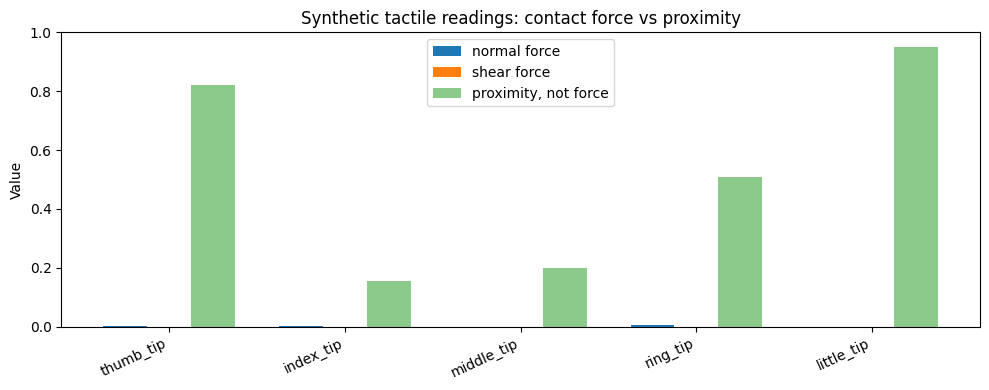

In [23]:
# Cell 9D: Visualize tactile contact vs proximity

import matplotlib.pyplot as plt
import numpy as np

normal = tactile_now[:, 0]
shear_mag = np.linalg.norm(tactile_now[:, 1:3], axis=1)
proximity = tactile_proximity

x = np.arange(len(finger_order))

plt.figure(figsize=(10, 4))
plt.bar(x - 0.25, normal, width=0.25, label="normal force")
plt.bar(x, shear_mag, width=0.25, label="shear force")
plt.bar(x + 0.25, proximity, width=0.25, label="proximity, not force", alpha=0.55)

plt.xticks(x, finger_order, rotation=25, ha="right")
plt.ylim(0, 1)
plt.ylabel("Value")
plt.title("Synthetic tactile readings: contact force vs proximity")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# Cell 10: Troubleshooting helpers and fallback options

TROUBLESHOOTING = r"""
OpenVLA Colab troubleshooting

1. CUDA unavailable
   Fix: Runtime -> Change runtime type -> GPU, then rerun Cell 1.
   Check: torch.cuda.is_available() should print True.

2. bitsandbytes not working
   Fix:
     %pip install -q --upgrade bitsandbytes accelerate
     Runtime -> Restart runtime
   Then rerun Cells 1, 4, and 5.

3. CUDA out of memory
   Fixes:
     - Make sure Cell 5 uses load_in_4bit=True.
     - Runtime -> Restart runtime to clear leaked VRAM.
     - Do not load another model in the same session.
     - Keep batch size at 1.
     - Use a small input image or upload a single image only.
     - Run cleanup_memory() before reloading.

4. Hugging Face 401 Unauthorized
   Fix:
     - Rerun Cell 2 and paste a valid hf_ token.
     - Make sure the token has Read access.
     - If using Colab Secrets, make sure the secret name is HF_TOKEN and notebook access is enabled.

5. Model gated/private access
   OpenVLA is public at the time this notebook was written. If access changes, open the model page while logged in,
   accept any license/access terms, then rerun Cell 2 and Cell 5.

6. transformers version mismatch
   Fix:
     %pip install -q --upgrade "transformers==4.40.1" "tokenizers==0.19.1" "timm==0.9.10"
     Runtime -> Restart runtime

7. PIL/Pillow import errors
   Fix:
     %pip install -q --upgrade pillow
     Runtime -> Restart runtime

8. Model loads on CPU accidentally
   Fix:
     - Confirm CUDA is available in Cell 1.
     - In Cell 5, keep device_map="auto" and quantization_config=quantization_config.
     - After loading, inspect the printed Device map. If many modules say cpu, inference will be very slow.

9. Session crashes due to RAM/VRAM
   Fix:
     - Restart runtime and run only this notebook.
     - Keep 4-bit loading enabled.
     - Avoid full precision or bf16 on T4.
     - Avoid simulation environments until this simple inference test works.

10. Action output shape confusion
    Expected for the main OpenVLA demo: 7 numbers.
    Meaning: [delta_x, delta_y, delta_z, delta_roll, delta_pitch, delta_yaw, gripper].
    These values are robot/action-space specific and are not automatically safe robot commands.

Fallback options if OpenVLA 7B still does not fit on T4

- Primary fallback: keep 4-bit quantization enabled. That is the practical T4 path.
- Restart the runtime and rerun only this notebook.
- CPU offload can be tried, but with 12.7 GB system RAM it may be very slow or unstable.
- OpenVLA's official action models are still 7B-scale. openvla/openvla-v01-7b is an older 7B model, not a tiny model.
- For a dry-run, load only the config and processor to verify token/access/custom-code plumbing without loading weights.
"""

print(TROUBLESHOOTING)

def clear_openvla_from_memory():
    """Delete model variables and clear CUDA cache before another load attempt."""
    global vla, processor, action, inputs
    for name in ["vla", "processor", "action", "inputs"]:
        if name in globals():
            del globals()[name]
    cleanup_memory()
    gpu_memory("After cleanup")

def dry_run_openvla_config(model_id="openvla/openvla-7b"):
    """Verify HF access, custom code loading, and processor loading without loading model weights."""
    from transformers import AutoConfig, AutoProcessor
    cfg = AutoConfig.from_pretrained(model_id, trust_remote_code=True)
    proc = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
    print("Config class:", type(cfg))
    print("Processor class:", type(proc))
    return cfg, proc

# Optional dry-run if full model loading fails:
# cfg, proc = dry_run_openvla_config()

# Advanced last-resort idea: 8-bit with CPU offload. This may be too slow or RAM-heavy on free Colab.
# from transformers import BitsAndBytesConfig
# offload_config = BitsAndBytesConfig(load_in_8bit=True, llm_int8_enable_fp32_cpu_offload=True)
# max_memory = {0: "13GiB", "cpu": "10GiB"}
# vla = AutoModelForVision2Seq.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.float16,
#     quantization_config=offload_config,
#     device_map="auto",
#     max_memory=max_memory,
#     low_cpu_mem_usage=True,
#     trust_remote_code=True,
# )


OpenVLA Colab troubleshooting

1. CUDA unavailable
   Fix: Runtime -> Change runtime type -> GPU, then rerun Cell 1.
   Check: torch.cuda.is_available() should print True.

2. bitsandbytes not working
   Fix:
     %pip install -q --upgrade bitsandbytes accelerate
     Runtime -> Restart runtime
   Then rerun Cells 1, 4, and 5.

3. CUDA out of memory
   Fixes:
     - Make sure Cell 5 uses load_in_4bit=True.
     - Runtime -> Restart runtime to clear leaked VRAM.
     - Do not load another model in the same session.
     - Keep batch size at 1.
     - Use a small input image or upload a single image only.
     - Run cleanup_memory() before reloading.

4. Hugging Face 401 Unauthorized
   Fix:
     - Rerun Cell 2 and paste a valid hf_ token.
     - Make sure the token has Read access.
     - If using Colab Secrets, make sure the secret name is HF_TOKEN and notebook access is enabled.

5. Model gated/private access
   OpenVLA is public at the time this notebook was written. If access chang

## Performance Notes

- A Tesla T4 with 15 GB VRAM is generally not enough for comfortable full precision OpenVLA 7B inference. Use 4-bit loading first.
- Inference may be slow on a T4, especially the first call after loading. Expect seconds per action, not real-time control.
- This notebook is only a simple one-shot inference demo. It is not a closed-loop robot simulation.
- Real robot control would require camera integration, safety limits, action unnormalization for the correct robot/dataset, and a low-level controller. OpenVLA is the high-level action prediction component, not the whole robot stack.